## Import Libraries

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random


import warnings
warnings.filterwarnings("ignore")


In [2]:
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Hyperparameters

In [3]:
BATCH_SIZE = 64
LR = 5e-4
EPOCHS = 60
NUM_CLASSES = 7


## Data Preprocessing & Augmentation

In [4]:
train_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

val_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


## Dataset Overview

#### Load the dataset

In [5]:
train_dataset = datasets.ImageFolder(
    "/kaggle/input/fer2013/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    "/kaggle/input/fer2013/test",
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print("Classes:", train_dataset.classes)


Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


#### Sample Images Visualization

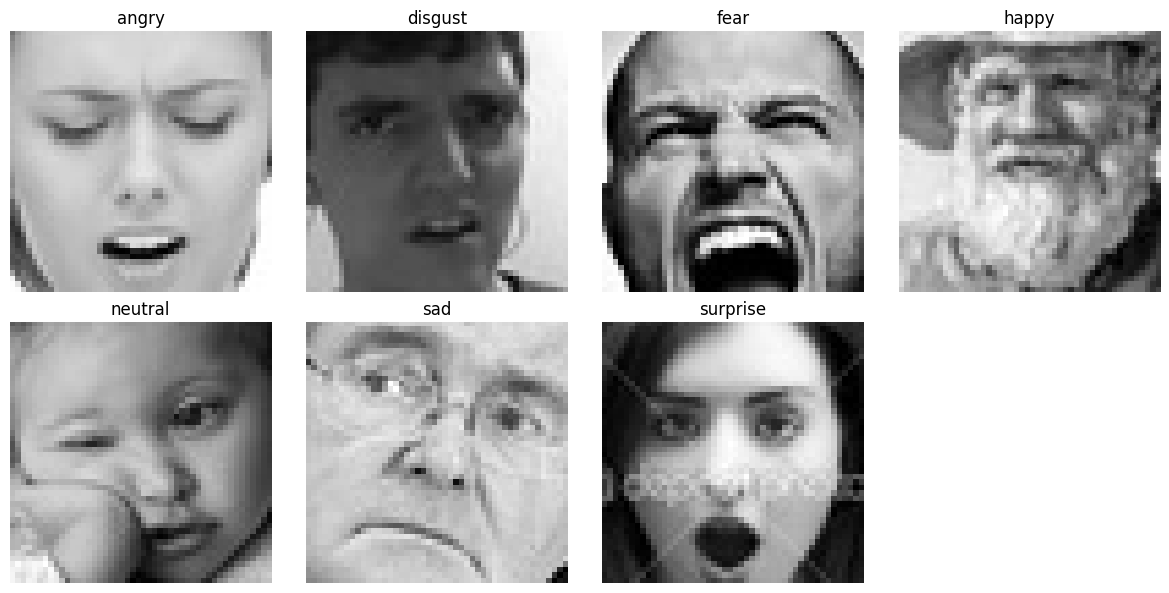

In [6]:

root_dir = train_dataset.root
classes = train_dataset.classes

plt.figure(figsize=(12,6))

for i, emotion in enumerate(classes):
    class_dir = os.path.join(root_dir, emotion)
    img_name = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, img_name)
    img = plt.imread(img_path)

    plt.subplot(2,4,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(emotion)
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Class Imbalance Handling



In [7]:
targets = [y for _, y in train_dataset.samples]
class_count = Counter(targets)

weights = torch.tensor(
    [1.0 / class_count[i] for i in range(NUM_CLASSES)],
    dtype=torch.float
).to(device)


## CNN Model Architecture


#### CNN from Scratch

In [8]:
class FER_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, 5, padding=2),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 3 * 3, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.25),

            nn.Linear(256, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.25),

            nn.Linear(512, NUM_CLASSES)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = FER_CNN().to(device)


#### Training Setup

In [9]:
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=LR)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)


#### Training Loop

In [10]:
train_loss, train_acc = [], []
val_loss, val_acc = [], []

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    loss_sum, correct, total = 0, 0, 0

    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            if train:
                optimizer.zero_grad()

            out = model(x)
            loss = criterion(out, y)

            if train:
                loss.backward()
                optimizer.step()

            loss_sum += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    return loss_sum / len(loader), correct / total


for epoch in range(EPOCHS):
    tr_l, tr_a = run_epoch(train_loader, True)
    va_l, va_a = run_epoch(val_loader, False)

    scheduler.step(va_a)

    train_loss.append(tr_l)
    train_acc.append(tr_a)
    val_loss.append(va_l)
    val_acc.append(va_a)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Acc: {tr_a:.4f} | Val Acc: {va_a:.4f}"
    )


Epoch [1/60] | Train Acc: 0.2199 | Val Acc: 0.2345
Epoch [2/60] | Train Acc: 0.3149 | Val Acc: 0.3536
Epoch [3/60] | Train Acc: 0.3890 | Val Acc: 0.4383
Epoch [4/60] | Train Acc: 0.4428 | Val Acc: 0.4632
Epoch [5/60] | Train Acc: 0.4746 | Val Acc: 0.5078
Epoch [6/60] | Train Acc: 0.4919 | Val Acc: 0.5322
Epoch [7/60] | Train Acc: 0.5187 | Val Acc: 0.5495
Epoch [8/60] | Train Acc: 0.5245 | Val Acc: 0.5708
Epoch [9/60] | Train Acc: 0.5412 | Val Acc: 0.5747
Epoch [10/60] | Train Acc: 0.5510 | Val Acc: 0.5736
Epoch [11/60] | Train Acc: 0.5540 | Val Acc: 0.5871
Epoch [12/60] | Train Acc: 0.5685 | Val Acc: 0.5942
Epoch [13/60] | Train Acc: 0.5759 | Val Acc: 0.5985
Epoch [14/60] | Train Acc: 0.5827 | Val Acc: 0.5999
Epoch [15/60] | Train Acc: 0.5870 | Val Acc: 0.6082
Epoch [16/60] | Train Acc: 0.5915 | Val Acc: 0.6017
Epoch [17/60] | Train Acc: 0.5958 | Val Acc: 0.6117
Epoch [18/60] | Train Acc: 0.6048 | Val Acc: 0.6073
Epoch [19/60] | Train Acc: 0.6066 | Val Acc: 0.6149
Epoch [20/60] | Train

#### Training vs Validation Accuracy

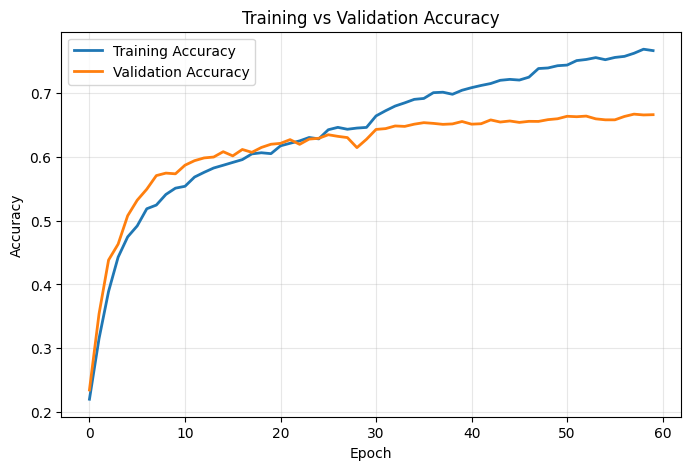

In [11]:
plt.figure(figsize=(8,5))
plt.plot(train_acc, label="Training Accuracy", linewidth=2)
plt.plot(val_acc, label="Validation Accuracy", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


#### Training vs Validation Loss

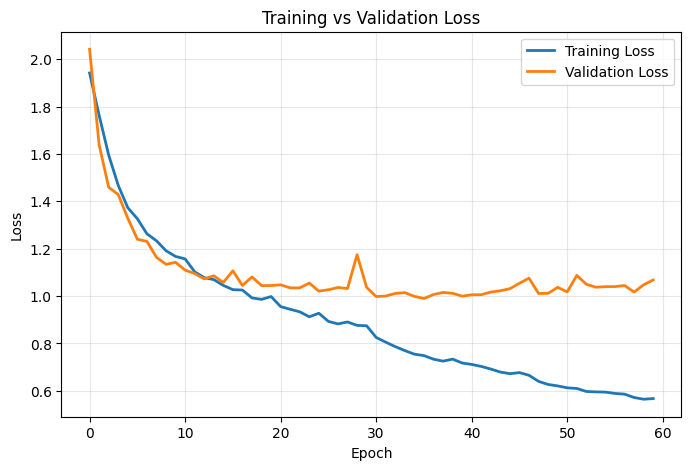

In [12]:
plt.figure(figsize=(8,5))
plt.plot(train_loss, label="Training Loss", linewidth=2)
plt.plot(val_loss, label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


#### Confusion Matrix


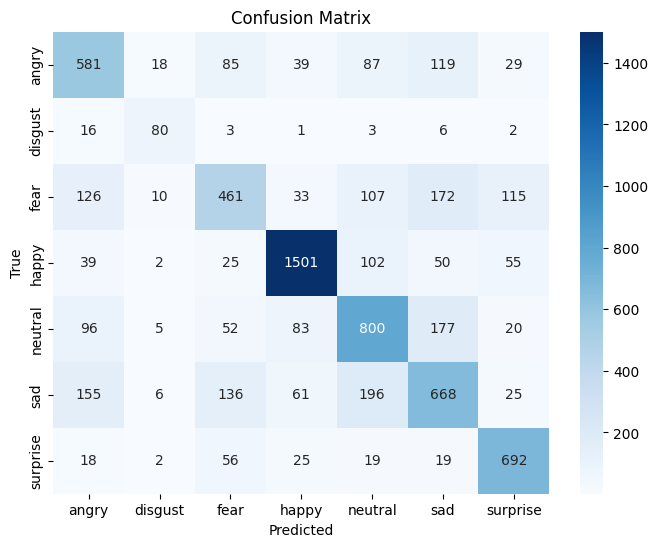

In [13]:
from sklearn.metrics import confusion_matrix

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        out = model(x)
        preds = out.argmax(1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(y.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


#### Prediction

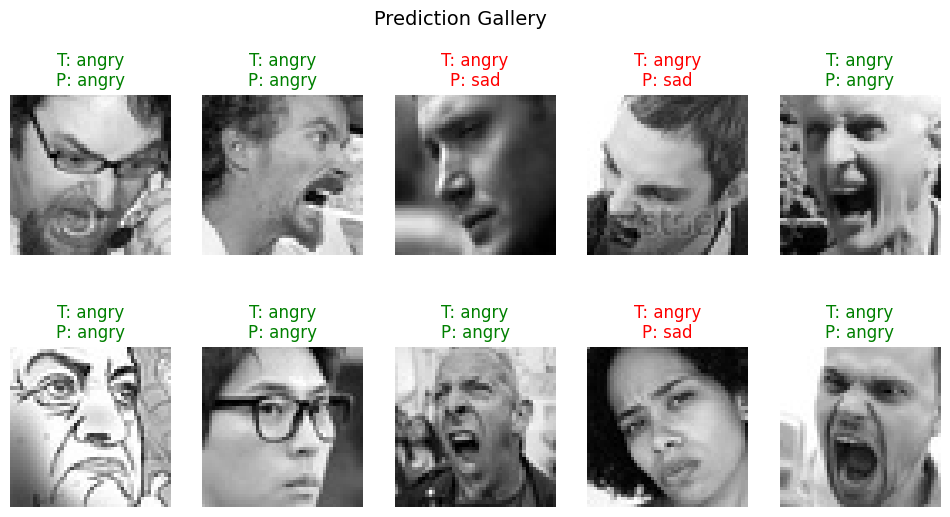

In [14]:
model.eval()
plt.figure(figsize=(12,6))
shown = 0

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(1)

        for i in range(x.size(0)):
            if shown >= 10:
                break

            img = x[i].cpu().squeeze()
            true = train_dataset.classes[y[i]]
            pred = train_dataset.classes[preds[i]]

            plt.subplot(2,5,shown+1)
            plt.imshow(img, cmap="gray")
            plt.title(
                f"T: {true}\nP: {pred}",
                color="green" if true == pred else "red"
            )
            plt.axis("off")
            shown += 1

        if shown >= 10:
            break

plt.suptitle("Prediction Gallery", fontsize=14)
plt.show()


In [ ]:
model.save('face_model.h5')